In [7]:
# create UHVDB/mine samplesheet

import polars as pl

assembly_config = pl.read_csv('real_samples/assembly_config.tsv', separator='\t')

with open('real_samples_min_samplesheet.csv', 'w') as f:
    f.write(
        'sample,tar,source_db,release,fasta\n'
    )

for row in assembly_config.iter_rows(named=True):
    sample = row['sample']
    tar = ""
    source_db = "REAL_SAMPLE_ASSEMBLY_BENCHMARK"
    release = "r2025_10"
    fasta = f'/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s9/real_samples/{sample}_megahit/final.contigs.fa'

    with open('real_samples_min_samplesheet.csv', 'a') as f:
        f.write(
            f'{sample}_megahit,{tar},{source_db},{release},{fasta}\n'
        )

    sample = row['sample']
    tar = ""
    source_db = "REAL_SAMPLE_ASSEMBLY_BENCHMARK"
    release = "r2025_10"
    fasta = f'/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s9/real_samples/cobra_{sample}/final.contigs.new.fa'

    with open('real_samples_min_samplesheet.csv', 'a') as f:
        f.write(
            f'{sample}_cobra,{tar},{source_db},{release},{fasta}\n'
        )

    sample = row['sample']
    tar = ""
    source_db = "REAL_SAMPLE_ASSEMBLY_BENCHMARK"
    release = "r2025_10"
    fasta = f'/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s9/real_samples/{sample}_megahit_high_kmer/final.contigs.fa'

    with open('real_samples_min_samplesheet.csv', 'a') as f:
        f.write(
            f'{sample}_high_kmer,{tar},{source_db},{release},{fasta}\n'
        )

f.close()

In [ ]:
%%bash
# # run UHVDB/mine on the samplesheet
# sbatch uhvdb_mine.sh

In [55]:
import glob

samples = list(set(pl.read_csv('real_samples_min_samplesheet.csv').with_columns(pl.col('sample').str.split('_').list[0])['sample']))
sample_count_dict = {sample: [] for sample in samples}

checkv_df_lst = []

for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/results/uhvdb/mine/real_sample_assembly_benchmark/r2025_10/*/uhvdb/virusfilter/*.tsv.gz'):
    base = file.split('/')[-4]
    sample, strategy = base.split('_', maxsplit=1)
    sample_count_dict[sample].append(strategy)
    df = (
        pl.read_csv(file, separator='\t')
            .with_columns([
                pl.col('completeness').cast(pl.String),
                pl.lit(sample).alias('sample'),
                pl.lit(strategy).alias('strategy')
            ])
    )
    checkv_df_lst.append(df[['seq_name', 'sample', 'strategy', 'uhvdb_virus_classification', 'completeness', 'contig_length']])

checkv_df = pl.concat(checkv_df_lst)

In [56]:
# identify samples with empty cobra output
for i in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s9/real_samples/cobra_*/blastdb_1.fa'):
    sample = i.split('/')[-2].split('_')[1]
    sample_count_dict[sample].append('cobra')

    checkv_df = pl.concat([
        checkv_df,
        (
            checkv_df
                .filter((pl.col('sample') == sample) & (pl.col('strategy') == 'megahit'))
                .with_columns([
                    pl.lit('cobra').alias('strategy')
                ])
        )
    ])

complete_samples = [sample for sample, count in sample_count_dict.items() if len(count) == 3]
len(complete_samples)

53

In [182]:
hq_viruses = (
    checkv_df
        .filter(
            (pl.col('completeness') != 'NA')
        )
        .filter(
            (pl.col('sample').is_in(complete_samples)) &
            (pl.col('completeness').cast(pl.Float64) >= 90) &
            (
                (pl.col('uhvdb_virus_classification') == 'confident')
            )
        )
        .join(pl.read_csv('real_samples/assembly_config.tsv', separator='\t')[['sample', 'body_site']], on='sample')
)

hq_viruses_per_sample = hq_viruses.group_by(['sample', 'strategy']).agg([pl.len(), pl.col('body_site').first()])

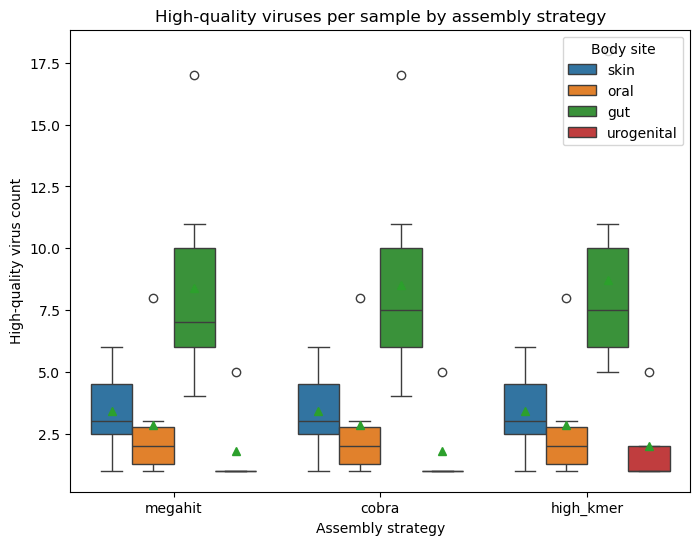

In [184]:
# boxplot maxlen by kmer
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=hq_viruses_per_sample, x='strategy', y='len', hue='body_site', showmeans=True)
plt.title('High-quality viruses per sample by assembly strategy')
plt.xlabel('Assembly strategy')
plt.ylabel('High-quality virus count')
plt.legend(title='Body site')
plt.show()

In [162]:
# parse megahit log to get N50 and max contig length for each k value
df_lst = []

# for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s9/real_samples/*_megahit*/log'):
# for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/assemble/*/*/*/megahit/*_cf.megahit.log'):
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/comprehensivity_analysis/results/uhvdb/assemble/*/*/*/megahit/megahit/*.megahit.log'):
    max_read_len = 0
    with open(file, 'r') as f:
        k_values = []
        n50_values = []
        max_len_values = []

        k = 0
        n50 = 0
        max_len = 0
        for line in f:
            if "max length'" in line:
                max_read_len = line.split()[-3].strip()
            if 'Assemble contigs from SdBG for k =' in line and 'k = 21' not in line:
                k_values.append(k)
                n50_values.append(n50)
                max_len_values.append(max_len)
                k = line.split(' ')[-1].strip()
            if 'Assemble contigs from SdBG for k =' in line and 'k = 21' in line:
                k = line.split(' ')[-1].strip()
            if 'Max:' in line and 'N50:' in line:
                n50 = int(line.split('N50: ')[-1].split(',')[0].strip())
                max_len = int(line.split('Max: ')[-1].split(',')[0].strip())
            if 'ALL DONE' in line:
                k_values.append(k)
                n50_values.append(n50)
                max_len_values.append(max_len)

        df = pl.DataFrame({
            'k': k_values,
            'n50': n50_values,
            'max_len': max_len_values
        })

    sample = file.split('/')[-2].split('_')[0]
    strategy = file.split('/')[-2].split('_', maxsplit=1)[-1]
    df = df.with_columns([
        pl.lit(sample).alias('sample'),
        pl.lit(strategy).alias('strategy'),
        pl.when(int(max_read_len) <= 100).then(pl.lit("<=100"))
            .when((int(max_read_len) > 100) & (int(max_read_len) <= 200)).then(pl.lit("101-200"))
            .when((int(max_read_len) > 200) & (int(max_read_len) <= 305)).then(pl.lit("201-300"))
            .when((int(max_read_len) > 300) & (int(max_read_len) <= 400)).then(pl.lit("300-400"))
            .otherwise(pl.lit(">350"))
            .alias('max_read_len')
    ])
    df_lst.append(df)

megahit_stats = pl.concat(df_lst)


In [163]:
megahit_stats.group_by(pl.col(['k', 'max_read_len'])).agg(pl.col('max_len').mean()).filter((pl.col('k') == '141') | (pl.col('k') == '251')).sort(['max_read_len', 'k'])

k,max_read_len,max_len
str,str,f64
"""141""","""101-200""",358788.407507
"""251""","""101-200""",431634.39726
"""141""","""201-300""",510305.285714
"""251""","""201-300""",674462.571429
"""141""","""<=100""",29573.545455
"""251""","""<=100""",29403.818182


In [164]:
megahit_stats.group_by(pl.col(['k', 'max_read_len'])).agg(pl.col('max_len').median()).filter((pl.col('k') == '141') | (pl.col('k') == '251')).sort(['max_read_len', 'k'])

k,max_read_len,max_len
str,str,f64
"""141""","""101-200""",326949.0
"""251""","""101-200""",375661.0
"""141""","""201-300""",329827.0
"""251""","""201-300""",574731.0
"""141""","""<=100""",13858.0
"""251""","""<=100""",13858.0


In [165]:
megahit_stats.group_by(pl.col(['k', 'max_read_len'])).agg(pl.col('n50').mean()).filter((pl.col('k') == '141') | (pl.col('k') == '251')).sort(['max_read_len', 'k'])

k,max_read_len,n50
str,str,f64
"""141""","""101-200""",29467.941019
"""251""","""101-200""",38037.241096
"""141""","""201-300""",3232.428571
"""251""","""201-300""",3143.428571
"""141""","""<=100""",2955.181818
"""251""","""<=100""",2935.636364


In [166]:
megahit_stats.group_by(pl.col(['k', 'max_read_len'])).agg(pl.col('n50').median()).filter((pl.col('k') == '141') | (pl.col('k') == '251')).sort(['max_read_len', 'k'])

k,max_read_len,n50
str,str,f64
"""141""","""101-200""",2554.0
"""251""","""101-200""",2324.0
"""141""","""201-300""",1821.0
"""251""","""201-300""",1742.0
"""141""","""<=100""",715.0
"""251""","""<=100""",626.0


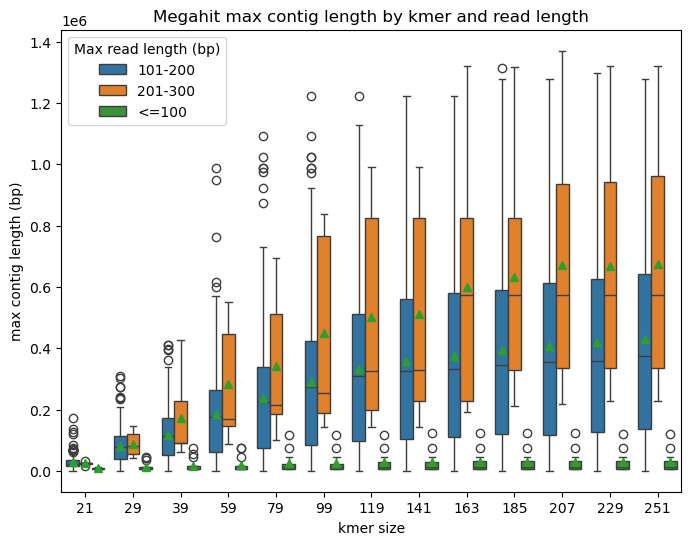

In [172]:
# boxplot maxlen by kmer
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=megahit_stats, x='k', y='max_len', hue='max_read_len', showmeans=True)
plt.title('Megahit max contig length by kmer and read length')
plt.xlabel('kmer size')
plt.ylabel('max contig length (bp)')
plt.legend(title='Max read length (bp)')
plt.show()
# plt.yscale('log')

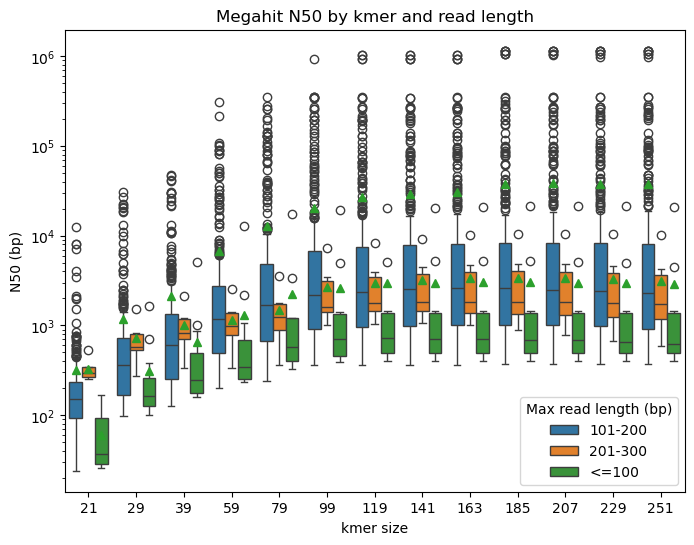

In [173]:
plt.figure(figsize=(8,6))
sns.boxplot(data=megahit_stats, x='k', y='n50', hue='max_read_len', showmeans=True)
plt.yscale('log')
plt.title('Megahit N50 by kmer and read length')
plt.xlabel('kmer size')
plt.ylabel('N50 (bp)')
plt.legend(title='Max read length (bp)')
plt.show()